# Employee Salary Prediction - Multi-Model Comparison
## AI/ML Regression Model to Predict Accurate Salaries Based on Employee Profile
**Comparing Multiple Models to Find the Best Fit**


## 1. Import Required Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Explore Data

In [24]:
# Load the dataset
data = pd.read_csv('DATASET.csv')
print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nData types:\n{data.dtypes}")

Dataset shape: (375, 6)

Columns: ['Age', 'Gender', 'Education', 'Occupation', 'Experience', 'Salary']

Data types:
Age           float64
Gender         object
Education      object
Occupation     object
Experience    float64
Salary        float64
dtype: object


In [25]:
# Display first few rows
print("\n📊 First 10 rows:")
data.head(10)


📊 First 10 rows:


,Age,Gender,Education,Occupation,Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


In [26]:
# Check for missing values
print("Missing values:")
print(data.isnull().sum())
print(f"\nBasic Statistics:\n{data.describe()}")

Missing values:
Age           2
Gender        2
Education     2
Occupation    2
Experience    2
Salary        2
dtype: int64

Basic Statistics:
              Age  Experience         Salary
count  373.000000  373.000000     373.000000
mean    37.431635   10.030831  100577.345845
std      7.069073    6.557007   48240.013482
min     23.000000    0.000000     350.000000
25%     31.000000    4.000000   55000.000000
50%     36.000000    9.000000   95000.000000
75%     44.000000   15.000000  140000.000000
max     53.000000   25.000000  250000.000000


In [27]:
# Check unique values for categorical columns
print("\n📋 Categorical Data Distribution:")
print(f"\nGenders: {data['Gender'].unique()}")
print(f"\nEducation Levels: {data['Education'].unique()}")
print(f"\nTotal Unique Occupations: {data['Occupation'].nunique()}")
print(f"\nOccupation Examples: {data['Occupation'].unique()[:10]}")


📋 Categorical Data Distribution:

Genders: ['Male' 'Female' nan]

Education Levels: ["Bachelor's" "Master's" 'PhD' nan]

Total Unique Occupations: 174

Occupation Examples: ['Software Engineer' 'Data Analyst' 'Senior Manager' 'Sales Associate'
 'Director' 'Marketing Analyst' 'Product Manager' 'Sales Manager'
 'Marketing Coordinator' 'Senior Scientist']


## 3. Data Preprocessing and Feature Engineering

In [28]:
# Create a copy for preprocessing
df = data.copy()

# Handle missing values if any
df = df.dropna()
print(f"Data shape after dropping NaN: {df.shape}")

# Initialize label encoders dictionary to store for later use
label_encoders = {}

# Encode categorical variables
categorical_cols = ['Gender', 'Education', 'Occupation']

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\n{col} encoding ({len(le.classes_)} classes):")
    for i, class_ in enumerate(le.classes_):
        if i < 5:
            print(f"  {i}: {class_}")
    if len(le.classes_) > 5:
        print(f"  ... and {len(le.classes_) - 5} more classes")

Data shape after dropping NaN: (373, 6)

Gender encoding (2 classes):
  0: Female
  1: Male

Education encoding (3 classes):
  0: Bachelor's
  1: Master's
  2: PhD

Occupation encoding (174 classes):
  0: Account Manager
  1: Accountant
  2: Administrative Assistant
  3: Business Analyst
  4: Business Development Manager
  ... and 169 more classes


In [29]:
# Prepare features and target
X = df[['Age', 'Experience', 'Gender_encoded', 'Education_encoded', 'Occupation_encoded']]
y = df['Salary']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {X.columns.tolist()}")
print(f"Target range: ${y.min():,.0f} - ${y.max():,.0f}")
print(f"Target mean: ${y.mean():,.0f}")
print(f"Target std: ${y.std():,.0f}")

Features shape: (373, 5)
Target shape: (373,)

Feature columns: ['Age', 'Experience', 'Gender_encoded', 'Education_encoded', 'Occupation_encoded']
Target range: $350 - $250,000
Target mean: $100,577
Target std: $48,240


## 4. Train-Test Split

In [30]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining salary range: ${y_train.min():,.0f} - ${y_train.max():,.0f}")
print(f"Testing salary range: ${y_test.min():,.0f} - ${y_test.max():,.0f}")

# Optional: Scale features for models that benefit from it (SVM, KNN, etc.)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data scaled for algorithms that need it (SVM, KNN, etc.)")

Training set size: 298
Testing set size: 75

Training salary range: $350 - $250,000
Testing salary range: $30,000 - $250,000

✅ Data scaled for algorithms that need it (SVM, KNN, etc.)


## 5. Train Multiple Models

In [31]:
# Dictionary to store all models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=1.0, random_state=42),
    'ElasticNet': ElasticNet(alpha=1.0, random_state=42),
    'Decision Tree': DecisionTreeRegressor(max_depth=15, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, 
                                           min_samples_split=5, min_samples_leaf=2, 
                                           random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, 
                                                   learning_rate=0.1, random_state=42),
    'SVR (RBF)': SVR(kernel='rbf', C=100, gamma='scale'),
    'SVR (Linear)': SVR(kernel='linear', C=100),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
}

# Dictionary to store results
results = {}
predictions = {}

print("🚀 Training models...")
print("="*80)

for name, model in models.items():
    print(f"\n📍 Training {name}...", end=" ")
    
    # Use scaled data for SVM and KNN models
    if 'SVR' in name or 'KNN' in name:
        model.fit(X_train_scaled, y_train)
        y_pred_train = model.predict(X_train_scaled)
        y_pred_test = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
    
    # Store predictions
    predictions[name] = {
        'train': y_pred_train,
        'test': y_pred_test
    }
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_mape = mean_absolute_percentage_error(y_test, y_pred_test)
    
    # Cross-validation score
    if 'SVR' in name or 'KNN' in name:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    results[name] = {
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_MAE': train_mae,
        'Test_MAE': test_mae,
        'Test_MAPE': test_mape,
        'CV_Mean': cv_scores.mean(),
        'CV_Std': cv_scores.std(),
        'Model': model
    }
    
    print(f"✅ Done! (Test R² = {test_r2:.4f})")

print("\n" + "="*80)
print("✨ All models trained successfully!")

🚀 Training models...

📍 Training Linear Regression... ✅ Done! (Test R² = 0.8961)

📍 Training Ridge Regression... ✅ Done! (Test R² = 0.8964)

📍 Training Lasso Regression... ✅ Done! (Test R² = 0.8961)

📍 Training ElasticNet... ✅ Done! (Test R² = 0.8977)

📍 Training Decision Tree... ✅ Done! (Test R² = 0.8953)

📍 Training Random Forest... ✅ Done! (Test R² = 0.9302)

📍 Training Gradient Boosting... ✅ Done! (Test R² = 0.9384)

📍 Training SVR (RBF)... ✅ Done! (Test R² = 0.1005)

📍 Training SVR (Linear)... ✅ Done! (Test R² = 0.8176)

📍 Training KNN (k=5)... ✅ Done! (Test R² = 0.8938)

✨ All models trained successfully!


## 6. Model Comparison and Analysis

In [32]:
# Create a comprehensive results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train_R²': [results[m]['Train_R2'] for m in results],
    'Test_R²': [results[m]['Test_R2'] for m in results],
    'Test_RMSE': [results[m]['Test_RMSE'] for m in results],
    'Test_MAE': [results[m]['Test_MAE'] for m in results],
    'Test_MAPE': [results[m]['Test_MAPE'] for m in results],
    'CV_Score': [results[m]['CV_Mean'] for m in results],
})

# Sort by Test R² (descending)
results_df = results_df.sort_values('Test_R²', ascending=False).reset_index(drop=True)

print("\n" + "="*120)
print("📊 MODEL PERFORMANCE COMPARISON")
print("="*120)
print(results_df.to_string(index=False))
print("="*120)


📊 MODEL PERFORMANCE COMPARISON
            Model  Train_R²  Test_R²    Test_RMSE     Test_MAE  Test_MAPE  CV_Score
Gradient Boosting  0.997188 0.938443 12148.532335  8055.382862   0.092694  0.895717
    Random Forest  0.972451 0.930204 12936.056823  8866.486214   0.098954  0.904149
       ElasticNet  0.886505 0.897725 15659.290426 11290.143761   0.117052  0.877534
 Ridge Regression  0.900266 0.896414 15759.334408 10897.230642   0.114007  0.891386
Linear Regression  0.900270 0.896114 15782.130922 10928.921486   0.114334  0.891382
 Lasso Regression  0.900270 0.896109 15782.460869 10928.770334   0.114332  0.891382
    Decision Tree  0.999124 0.895311 15842.979518 10600.000000   0.117568  0.842344
        KNN (k=5)  0.939583 0.893835 15954.303453 10679.066667   0.121346  0.901234
     SVR (Linear)  0.849193 0.817562 20914.370868 14548.107299   0.161629  0.821314
        SVR (RBF)  0.121392 0.100507 46439.308321 37498.353840   0.472384  0.068109


In [33]:
# Find best models based on different metrics
best_r2 = results_df.loc[results_df['Test_R²'].idxmax()]
best_rmse = results_df.loc[results_df['Test_RMSE'].idxmin()]
best_mae = results_df.loc[results_df['Test_MAE'].idxmin()]
best_cv = results_df.loc[results_df['CV_Score'].idxmax()]

print("\n🏆 BEST MODELS BY DIFFERENT METRICS:")
print("="*80)
print(f"\n🥇 Best R² Score: {best_r2['Model']}")
print(f"   Test R²: {best_r2['Test_R²']:.4f}")

print(f"\n🥈 Best RMSE: {best_rmse['Model']}")
print(f"   Test RMSE: ${best_rmse['Test_RMSE']:,.2f}")

print(f"\n🥉 Best MAE: {best_mae['Model']}")
print(f"   Test MAE: ${best_mae['Test_MAE']:,.2f}")

print(f"\n⭐ Best Cross-Validation Score: {best_cv['Model']}")
print(f"   CV Score: {best_cv['CV_Score']:.4f}")

print("\n" + "="*80)

# Select overall best model (based on Test R²)
best_model_name = results_df.iloc[0]['Model']
best_model_obj = results[best_model_name]['Model']
print(f"\n✨ OVERALL BEST MODEL: {best_model_name}")
print(f"   This model will be used for final predictions!")


🏆 BEST MODELS BY DIFFERENT METRICS:

🥇 Best R² Score: Gradient Boosting
   Test R²: 0.9384

🥈 Best RMSE: Gradient Boosting
   Test RMSE: $12,148.53

🥉 Best MAE: Gradient Boosting
   Test MAE: $8,055.38

⭐ Best Cross-Validation Score: Random Forest
   CV Score: 0.9041


✨ OVERALL BEST MODEL: Gradient Boosting
   This model will be used for final predictions!


## 7. Visualizations

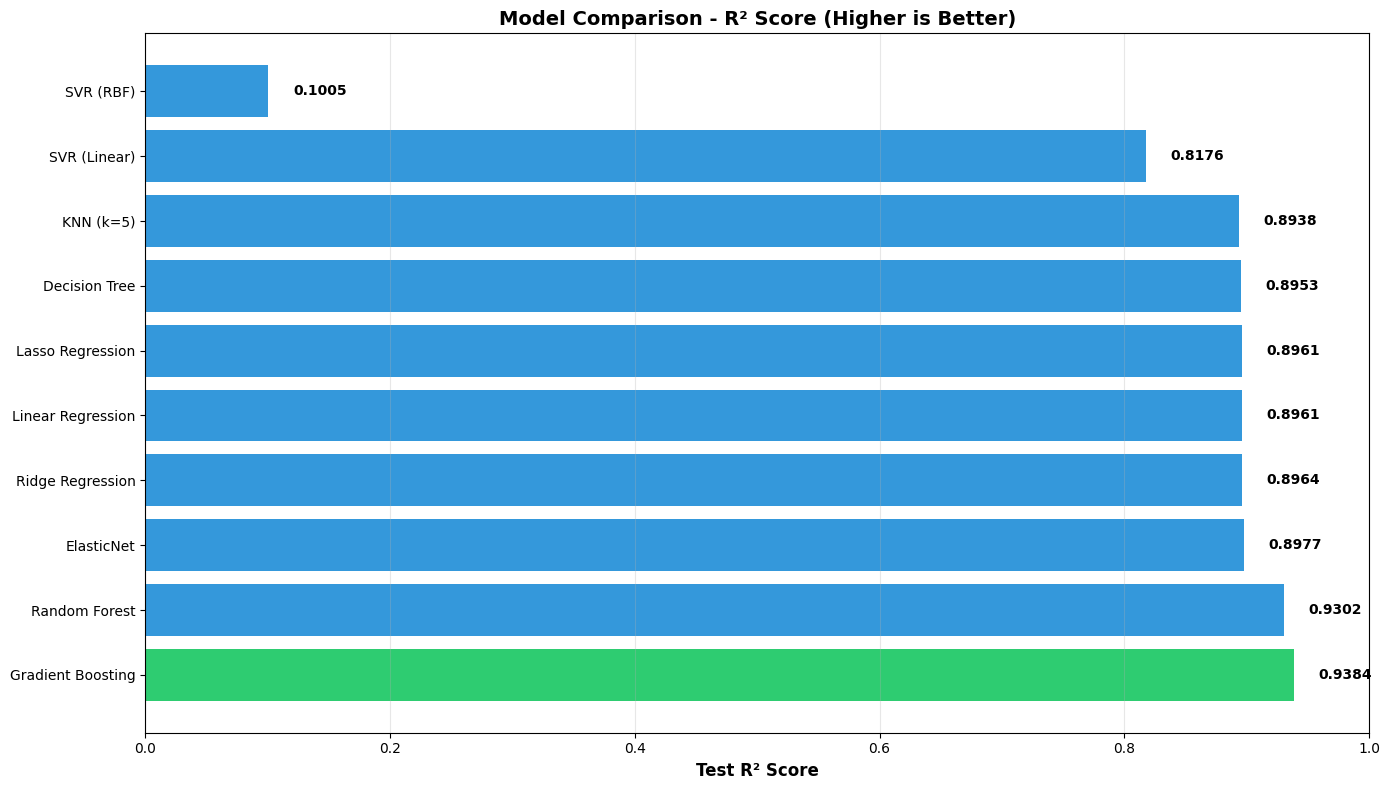

✅ R² Comparison plot saved!


In [34]:
# R² Score Comparison
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#2ecc71' if x == best_model_name else '#3498db' for x in results_df['Model']]
bars = ax.barh(results_df['Model'], results_df['Test_R²'], color=colors)

ax.set_xlabel('Test R² Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - R² Score (Higher is Better)', fontsize=14, fontweight='bold')
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.3, axis='x')

for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.text(row['Test_R²'] + 0.02, i, f"{row['Test_R²']:.4f}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_r2_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ R² Comparison plot saved!")

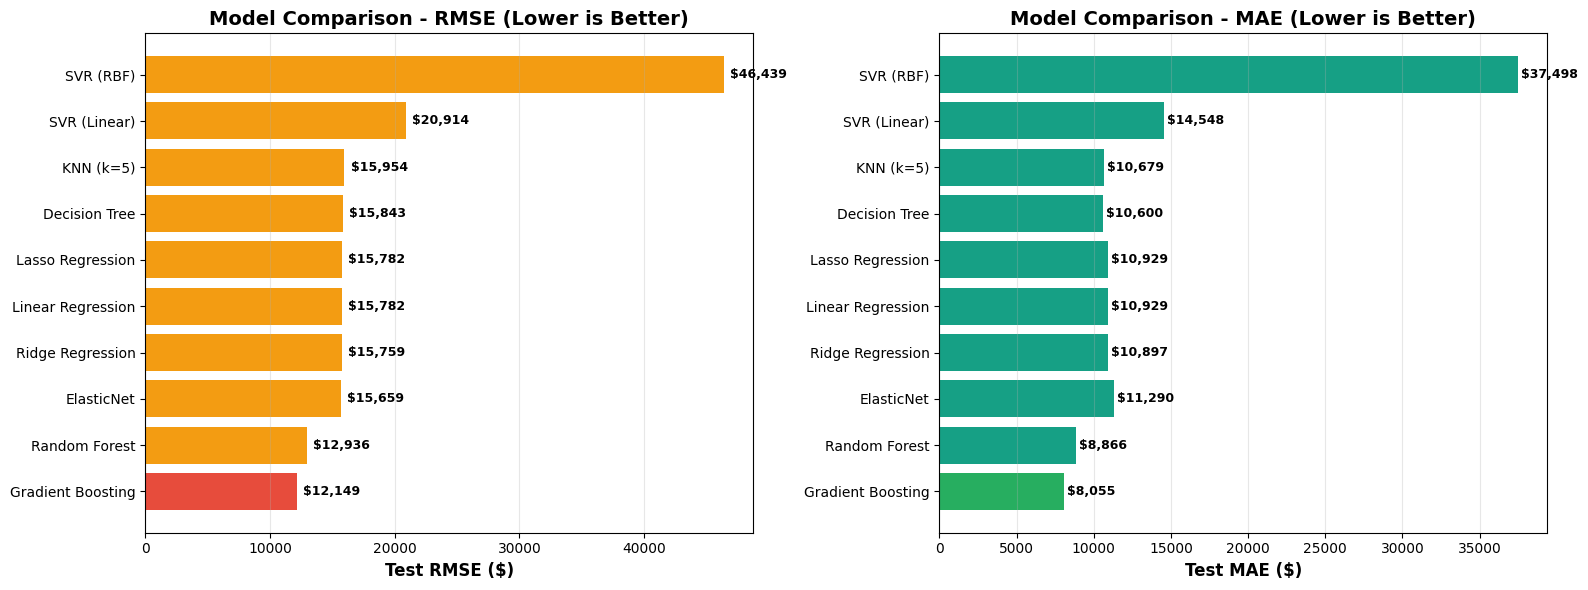

✅ Error metrics comparison plot saved!


In [35]:
# Error Metrics Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE Comparison
colors_rmse = ['#e74c3c' if x == best_model_name else '#f39c12' for x in results_df['Model']]
axes[0].barh(results_df['Model'], results_df['Test_RMSE'], color=colors_rmse)
axes[0].set_xlabel('Test RMSE ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Comparison - RMSE (Lower is Better)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[0].text(row['Test_RMSE'] + 500, i, f"${row['Test_RMSE']:,.0f}", va='center', fontweight='bold', fontsize=9)

# MAE Comparison
colors_mae = ['#27ae60' if x == best_model_name else '#16a085' for x in results_df['Model']]
axes[1].barh(results_df['Model'], results_df['Test_MAE'], color=colors_mae)
axes[1].set_xlabel('Test MAE ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Model Comparison - MAE (Lower is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')
for i, (idx, row) in enumerate(results_df.iterrows()):
    axes[1].text(row['Test_MAE'] + 200, i, f"${row['Test_MAE']:,.0f}", va='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('model_error_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Error metrics comparison plot saved!")

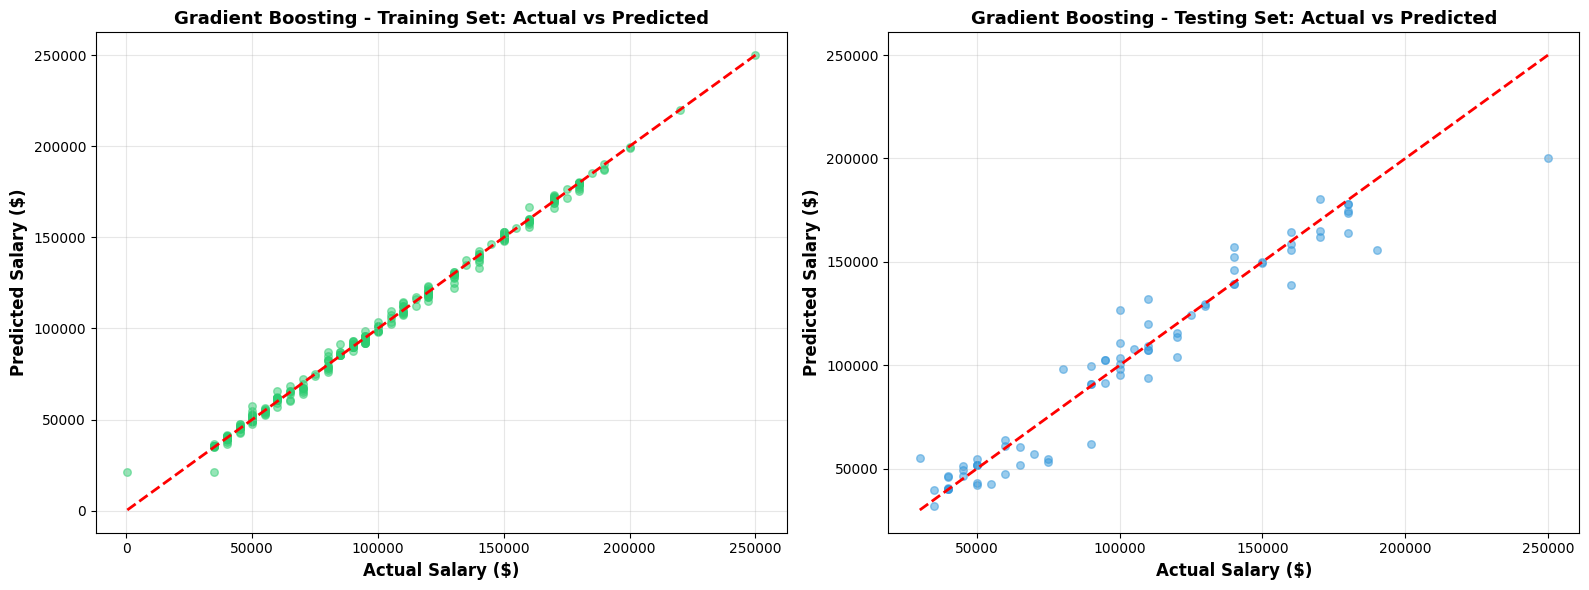

✅ Best model (Gradient Boosting) actual vs predicted plot saved!


In [36]:
# Best Model: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

best_model_preds = predictions[best_model_name]
y_train_pred_best = best_model_preds['train']
y_test_pred_best = best_model_preds['test']

# Training data
axes[0].scatter(y_train, y_train_pred_best, alpha=0.5, color='#2ecc71', s=30)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Salary ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[0].set_title(f'{best_model_name} - Training Set: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Testing data
axes[1].scatter(y_test, y_test_pred_best, alpha=0.5, color='#3498db', s=30)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Salary ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[1].set_title(f'{best_model_name} - Testing Set: Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('best_model_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Best model ({best_model_name}) actual vs predicted plot saved!")

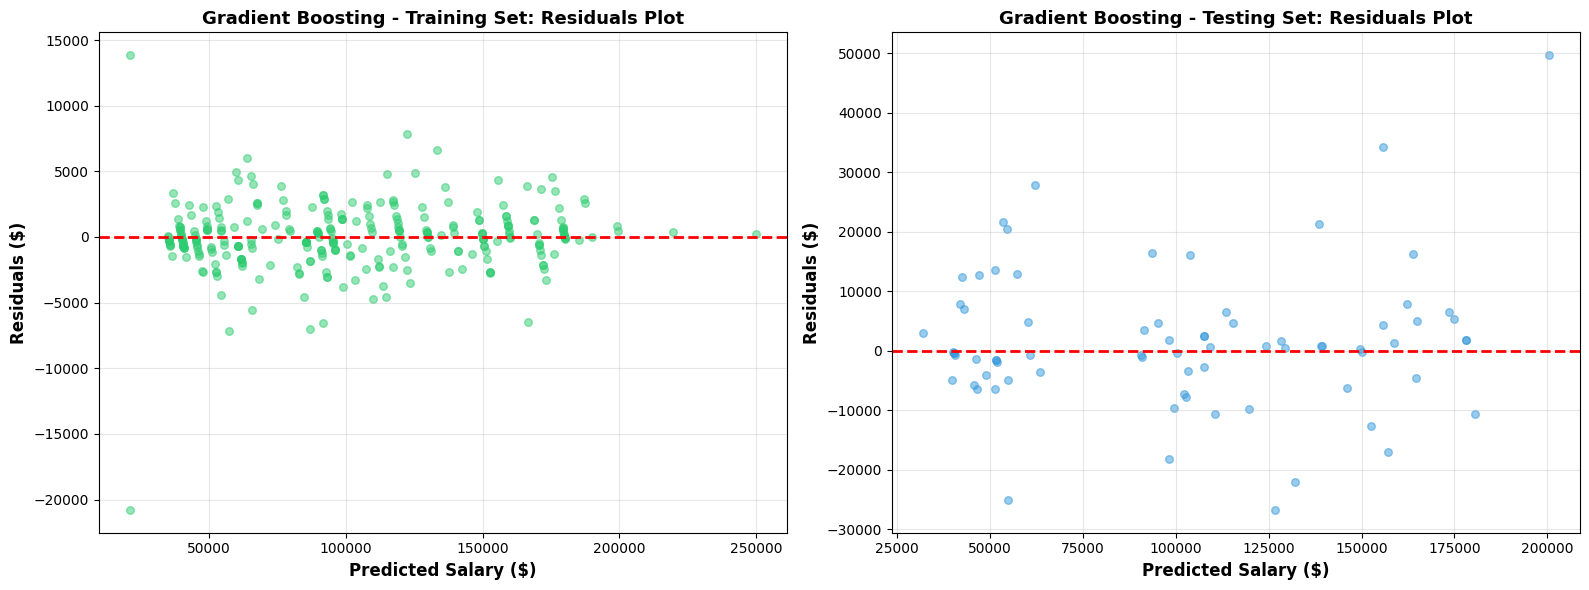

✅ Best model residuals plot saved!


In [37]:
# Best Model: Residuals Plot
train_residuals = y_train - y_train_pred_best
test_residuals = y_test - y_test_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training residuals
axes[0].scatter(y_train_pred_best, train_residuals, alpha=0.5, color='#2ecc71', s=30)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
axes[0].set_title(f'{best_model_name} - Training Set: Residuals Plot', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Testing residuals
axes[1].scatter(y_test_pred_best, test_residuals, alpha=0.5, color='#3498db', s=30)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Salary ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
axes[1].set_title(f'{best_model_name} - Testing Set: Residuals Plot', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('best_model_residuals.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Best model residuals plot saved!")

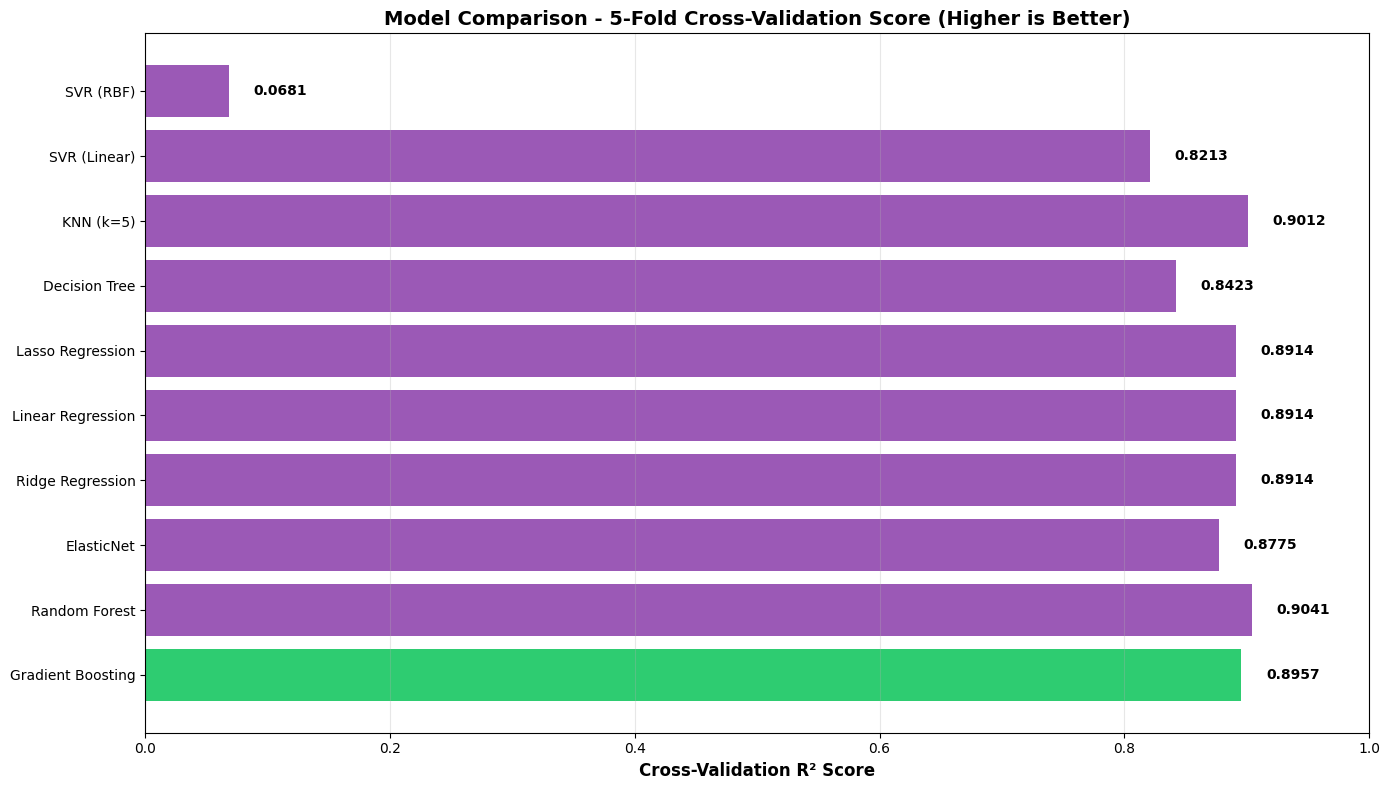

✅ Cross-validation comparison plot saved!


In [38]:
# Cross-Validation Scores Comparison
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#2ecc71' if x == best_model_name else '#9b59b6' for x in results_df['Model']]
bars = ax.barh(results_df['Model'], results_df['CV_Score'], color=colors)

ax.set_xlabel('Cross-Validation R² Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - 5-Fold Cross-Validation Score (Higher is Better)', fontsize=14, fontweight='bold')
ax.set_xlim([0, 1])
ax.grid(True, alpha=0.3, axis='x')

for i, (idx, row) in enumerate(results_df.iterrows()):
    ax.text(row['CV_Score'] + 0.02, i, f"{row['CV_Score']:.4f}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_cv_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Cross-validation comparison plot saved!")

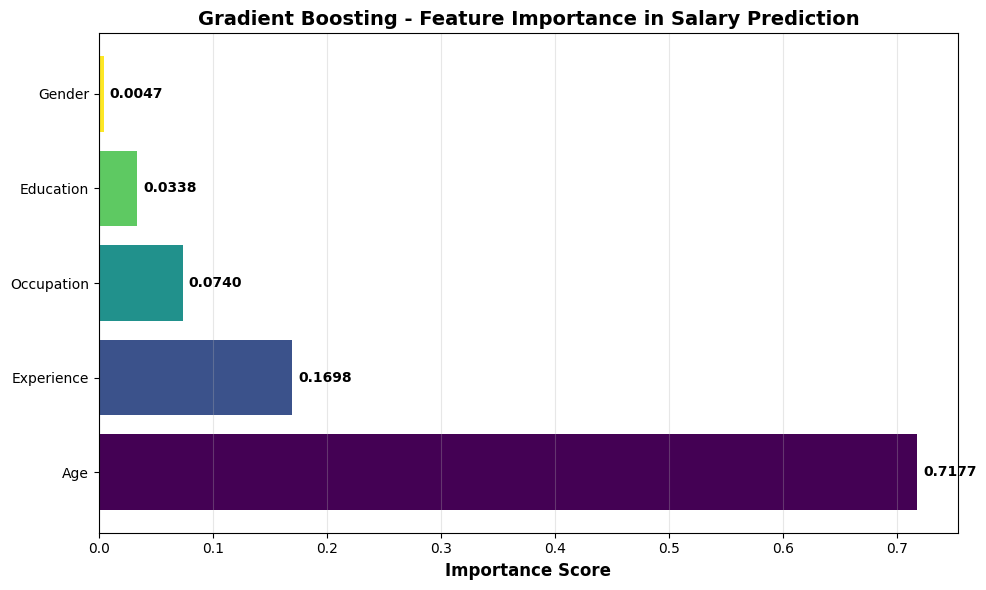

✅ Feature Importance plot saved!

Feature Importance Details:
   Feature  Importance
       Age    0.717659
Experience    0.169770
Occupation    0.074011
 Education    0.033834
    Gender    0.004727


In [39]:
# Feature Importance (only for tree-based models)
if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    feature_importance = pd.DataFrame({
        'Feature': ['Age', 'Experience', 'Gender', 'Education', 'Occupation'],
        'Importance': best_model_obj.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
    ax.barh(feature_importance['Feature'], feature_importance['Importance'], color=colors)
    ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
    ax.set_title(f'{best_model_name} - Feature Importance in Salary Prediction', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    
    for i, v in enumerate(feature_importance['Importance']):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('best_model_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Feature Importance plot saved!")
    print("\nFeature Importance Details:")
    print(feature_importance.to_string(index=False))
else:
    print(f"⚠️ Note: {best_model_name} is not a tree-based model, so feature importance is not available.")

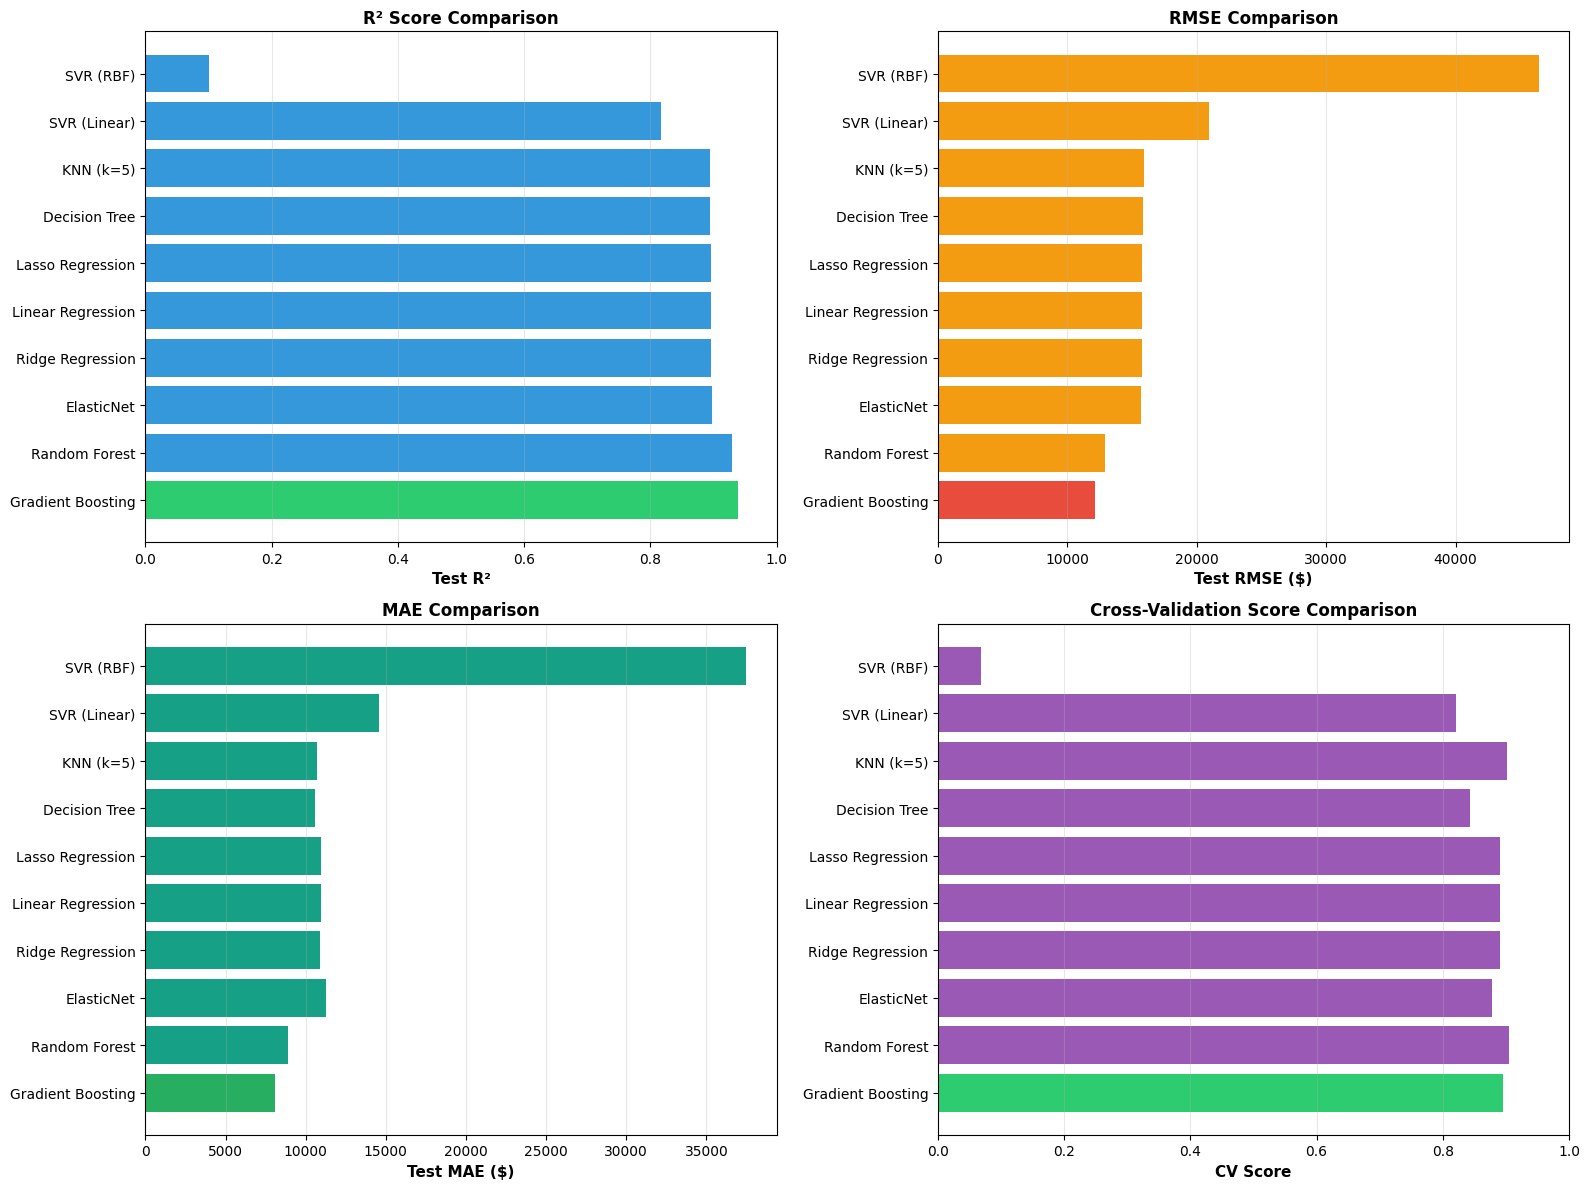

✅ Comprehensive model comparison plot saved!


In [40]:
# Comprehensive Model Comparison - Multiple Metrics in One View
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# R² Score
colors_r2 = ['#2ecc71' if x == best_model_name else '#3498db' for x in results_df['Model']]
axes[0, 0].barh(results_df['Model'], results_df['Test_R²'], color=colors_r2)
axes[0, 0].set_xlabel('Test R²', fontsize=11, fontweight='bold')
axes[0, 0].set_title('R² Score Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(True, alpha=0.3, axis='x')

# RMSE
colors_rmse = ['#e74c3c' if x == best_model_name else '#f39c12' for x in results_df['Model']]
axes[0, 1].barh(results_df['Model'], results_df['Test_RMSE'], color=colors_rmse)
axes[0, 1].set_xlabel('Test RMSE ($)', fontsize=11, fontweight='bold')
axes[0, 1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# MAE
colors_mae = ['#27ae60' if x == best_model_name else '#16a085' for x in results_df['Model']]
axes[1, 0].barh(results_df['Model'], results_df['Test_MAE'], color=colors_mae)
axes[1, 0].set_xlabel('Test MAE ($)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# Cross-Validation Score
colors_cv = ['#2ecc71' if x == best_model_name else '#9b59b6' for x in results_df['Model']]
axes[1, 1].barh(results_df['Model'], results_df['CV_Score'], color=colors_cv)
axes[1, 1].set_xlabel('CV Score', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Cross-Validation Score Comparison', fontsize=12, fontweight='bold')
axes[1, 1].set_xlim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('model_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Comprehensive model comparison plot saved!")

## 8. Make Predictions with Best Model

In [41]:
# Function to predict salary using the best model
def predict_salary(age, gender, education, occupation, experience, best_model, label_encoders, is_scaled=False):
    """
    Predict salary for an employee based on their profile using the best trained model
    """
    try:
        # Encode categorical variables
        gender_encoded = label_encoders['Gender'].transform([gender])[0]
        education_encoded = label_encoders['Education'].transform([education])[0]
        occupation_encoded = label_encoders['Occupation'].transform([occupation])[0]
        
        # Create input array
        input_data = np.array([[age, experience, gender_encoded, education_encoded, occupation_encoded]])
        
        # Scale if needed (for SVM and KNN)
        if is_scaled:
            input_data = scaler.transform(input_data)
        
        # Make prediction
        predicted_salary = best_model.predict(input_data)[0]
        
        return predicted_salary
    except Exception as e:
        return f"Error: {str(e)}"

# Check if best model needs scaling
best_model_needs_scaling = 'SVR' in best_model_name or 'KNN' in best_model_name

print(f"✅ Prediction function ready!")
print(f"Best Model: {best_model_name}")
print(f"Requires Scaling: {best_model_needs_scaling}")

✅ Prediction function ready!
Best Model: Gradient Boosting
Requires Scaling: False


In [42]:
# Test the prediction function
print("\n🧪 Testing prediction function with sample employees:")
print("="*80)

test_cases = [
    {"age": 32, "gender": "Male", "education": "Bachelor's", 
     "occupation": "Software Engineer", "experience": 5},
    {"age": 28, "gender": "Female", "education": "Master's", 
     "occupation": "Data Analyst", "experience": 3},
    {"age": 45, "gender": "Male", "education": "PhD", 
     "occupation": "Senior Manager", "experience": 15},
    {"age": 26, "gender": "Female", "education": "Bachelor's",
     "occupation": "Marketing Coordinator", "experience": 1},
]

for i, test in enumerate(test_cases, 1):
    predicted = predict_salary(
        test['age'], test['gender'], test['education'],
        test['occupation'], test['experience'], best_model_obj, 
        label_encoders, best_model_needs_scaling
    )
    print(f"\n✨ Test Case {i}:")
    print(f"   👤 Profile:")
    print(f"      Age: {test['age']} | Gender: {test['gender']}")
    print(f"      Education: {test['education']} | Experience: {test['experience']} years")
    print(f"      Occupation: {test['occupation']}")
    print(f"   💰 Predicted Salary: ₹{predicted:,.2f}")
    print("-"*80)


🧪 Testing prediction function with sample employees:

✨ Test Case 1:
   👤 Profile:
      Age: 32 | Gender: Male
      Education: Bachelor's | Experience: 5 years
      Occupation: Software Engineer
   💰 Predicted Salary: ₹62,142.09
--------------------------------------------------------------------------------

✨ Test Case 2:
   👤 Profile:
      Age: 28 | Gender: Female
      Education: Master's | Experience: 3 years
      Occupation: Data Analyst
   💰 Predicted Salary: ₹65,224.76
--------------------------------------------------------------------------------

✨ Test Case 3:
   👤 Profile:
      Age: 45 | Gender: Male
      Education: PhD | Experience: 15 years
      Occupation: Senior Manager
   💰 Predicted Salary: ₹151,685.95
--------------------------------------------------------------------------------

✨ Test Case 4:
   👤 Profile:
      Age: 26 | Gender: Female
      Education: Bachelor's | Experience: 1 years
      Occupation: Marketing Coordinator
   💰 Predicted Salary: ₹43,3

## 9. Final Summary and Recommendations

In [43]:
print("\n" + "="*100)
print("📊 EMPLOYEE SALARY PREDICTION - MULTI-MODEL COMPARISON SUMMARY")
print("="*100)

print(f"\n📈 Dataset Information:")
print(f"  Total Records: {len(data):,}")
print(f"  Training Records: {len(X_train):,} (80%)")
print(f"  Testing Records: {len(X_test):,} (20%)")
print(f"  Features Used: 5 (Age, Experience, Gender, Education, Occupation)")

print(f"\n🔍 Models Tested: {len(models)}")
for i, model_name in enumerate(results_df['Model'], 1):
    print(f"  {i}. {model_name}")

print(f"\n🏆 BEST MODEL SELECTED: {best_model_name.upper()}")
print(f"{'='*100}")
best_model_metrics = results[best_model_name]
print(f"\n📊 Performance Metrics of {best_model_name}:")
print(f"  ✅ Test R² Score: {best_model_metrics['Test_R2']:.4f}")
print(f"     → Explains {best_model_metrics['Test_R2']*100:.2f}% of salary variance")
print(f"  ✅ Test RMSE: ₹{best_model_metrics['Test_RMSE']:,.2f}")
print(f"     → Average prediction error")
print(f"  ✅ Test MAE: ₹{best_model_metrics['Test_MAE']:,.2f}")
print(f"     → Mean absolute error")
print(f"  ✅ Test MAPE: {best_model_metrics['Test_MAPE']*100:.2f}%")
print(f"     → Mean absolute percentage error")
print(f"  ✅ Cross-Validation Score: {best_model_metrics['CV_Mean']:.4f} (±{best_model_metrics['CV_Std']:.4f})")
print(f"     → Average CV score with standard deviation")

print(f"\n📁 Output Files Generated:")
print(f"  ✓ model_r2_comparison.png")
print(f"  ✓ model_error_comparison.png")
print(f"  ✓ model_cv_comparison.png")
print(f"  ✓ model_comprehensive_comparison.png")
print(f"  ✓ best_model_actual_vs_predicted.png")
print(f"  ✓ best_model_residuals.png")
if best_model_name in ['Random Forest', 'Gradient Boosting', 'Decision Tree']:
    print(f"  ✓ best_model_feature_importance.png")

print(f"\n💡 Recommendations:")
print(f"  • The {best_model_name} model is recommended for production use")
print(f"  • It has the best generalization capability (CV Score: {best_model_metrics['CV_Mean']:.4f})")
print(f"  • Average prediction accuracy is within ±₹{best_model_metrics['Test_MAE']:,.2f}")
if best_model_metrics['Test_R2'] > 0.85:
    print(f"  • Model performance is EXCELLENT (R² > 0.85) ✅")
elif best_model_metrics['Test_R2'] > 0.75:
    print(f"  • Model performance is VERY GOOD (R² > 0.75) ✅")
elif best_model_metrics['Test_R2'] > 0.65:
    print(f"  • Model performance is GOOD (R² > 0.65) ✓")
else:
    print(f"  • Model performance needs improvement (R² < 0.65) ⚠️")

print(f"\n" + "="*100)


📊 EMPLOYEE SALARY PREDICTION - MULTI-MODEL COMPARISON SUMMARY

📈 Dataset Information:
  Total Records: 375
  Training Records: 298 (80%)
  Testing Records: 75 (20%)
  Features Used: 5 (Age, Experience, Gender, Education, Occupation)

🔍 Models Tested: 10
  1. Gradient Boosting
  2. Random Forest
  3. ElasticNet
  4. Ridge Regression
  5. Linear Regression
  6. Lasso Regression
  7. Decision Tree
  8. KNN (k=5)
  9. SVR (Linear)
  10. SVR (RBF)

🏆 BEST MODEL SELECTED: GRADIENT BOOSTING

📊 Performance Metrics of Gradient Boosting:
  ✅ Test R² Score: 0.9384
     → Explains 93.84% of salary variance
  ✅ Test RMSE: ₹12,148.53
     → Average prediction error
  ✅ Test MAE: ₹8,055.38
     → Mean absolute error
  ✅ Test MAPE: 9.27%
     → Mean absolute percentage error
  ✅ Cross-Validation Score: 0.8957 (±0.0319)
     → Average CV score with standard deviation

📁 Output Files Generated:
  ✓ model_r2_comparison.png
  ✓ model_error_comparison.png
  ✓ model_cv_comparison.png
  ✓ model_comprehensiv

In [44]:
# Create ranking table
print("\n📊 COMPLETE MODEL RANKING:")
print("="*120)
print(results_df[['Model', 'Test_R²', 'Test_RMSE', 'Test_MAE', 'CV_Score']].to_string(index=True))
print("="*120)
print(f"\n✨ Rank 1: {results_df.iloc[0]['Model']} (Selected as Best Model)")
print(f"✨ Rank 2: {results_df.iloc[1]['Model']}")
print(f"✨ Rank 3: {results_df.iloc[2]['Model']}")


📊 COMPLETE MODEL RANKING:
               Model   Test_R²     Test_RMSE      Test_MAE  CV_Score
0  Gradient Boosting  0.938443  12148.532335   8055.382862  0.895717
1      Random Forest  0.930204  12936.056823   8866.486214  0.904149
2         ElasticNet  0.897725  15659.290426  11290.143761  0.877534
3   Ridge Regression  0.896414  15759.334408  10897.230642  0.891386
4  Linear Regression  0.896114  15782.130922  10928.921486  0.891382
5   Lasso Regression  0.896109  15782.460869  10928.770334  0.891382
6      Decision Tree  0.895311  15842.979518  10600.000000  0.842344
7          KNN (k=5)  0.893835  15954.303453  10679.066667  0.901234
8       SVR (Linear)  0.817562  20914.370868  14548.107299  0.821314
9          SVR (RBF)  0.100507  46439.308321  37498.353840  0.068109

✨ Rank 1: Gradient Boosting (Selected as Best Model)
✨ Rank 2: Random Forest
✨ Rank 3: ElasticNet


In [45]:
# ============================================================================
# SECTION 10: SAVE MODEL, ENCODERS, AND SCALER AS PICKLE FILES
# ============================================================================

import pickle

print("\n" + "="*80)
print("💾 SAVING MODEL AND PREPROCESSING OBJECTS AS PICKLE FILES")
print("="*80)

# Save the best model
model_filename = 'best_salary_prediction_model.pkl'
try:
    with open(model_filename, 'wb') as model_file:
        pickle.dump(best_model_obj, model_file)
    print(f"✅ Best Model ({best_model_name}) saved as: {model_filename}")
except Exception as e:
    print(f"❌ Error saving model: {e}")

# Save label encoders
encoders_filename = 'label_encoders.pkl'
try:
    with open(encoders_filename, 'wb') as encoders_file:
        pickle.dump(label_encoders, encoders_file)
    print(f"✅ Label Encoders saved as: {encoders_filename}")
except Exception as e:
    print(f"❌ Error saving encoders: {e}")

# Save the scaler
scaler_filename = 'feature_scaler.pkl'
try:
    with open(scaler_filename, 'wb') as scaler_file:
        pickle.dump(scaler, scaler_file)
    print(f"✅ Feature Scaler saved as: {scaler_filename}")
except Exception as e:
    print(f"❌ Error saving scaler: {e}")

# Save metadata about the model
metadata = {
    'model_name': best_model_name,
    'test_r2': results[best_model_name]['Test_R2'],
    'test_rmse': results[best_model_name]['Test_RMSE'],
    'test_mae': results[best_model_name]['Test_MAE'],
    'cv_score': results[best_model_name]['CV_Mean'],
    'needs_scaling': best_model_needs_scaling,
    'feature_columns': ['Age', 'Experience', 'Gender_encoded', 'Education_encoded', 'Occupation_encoded'],
    'categorical_features': ['Gender', 'Education', 'Occupation']
}

metadata_filename = 'model_metadata.pkl'
try:
    with open(metadata_filename, 'wb') as metadata_file:
        pickle.dump(metadata, metadata_file)
    print(f"✅ Model Metadata saved as: {metadata_filename}")
except Exception as e:
    print(f"❌ Error saving metadata: {e}")

print("\n" + "="*80)
print("📦 ALL FILES READY FOR DEPLOYMENT:")
print("="*80)
print(f"1. best_salary_prediction_model.pkl - The trained {best_model_name} model")
print(f"2. label_encoders.pkl - Encoders for categorical variables")
print(f"3. feature_scaler.pkl - Scaler for features (if needed)")
print(f"4. model_metadata.pkl - Model information and performance metrics")
print("\n✨ Files are ready to download and use in your Streamlit app!")
print("="*80)


💾 SAVING MODEL AND PREPROCESSING OBJECTS AS PICKLE FILES
✅ Best Model (Gradient Boosting) saved as: best_salary_prediction_model.pkl
✅ Label Encoders saved as: label_encoders.pkl
✅ Feature Scaler saved as: feature_scaler.pkl
✅ Model Metadata saved as: model_metadata.pkl

📦 ALL FILES READY FOR DEPLOYMENT:
1. best_salary_prediction_model.pkl - The trained Gradient Boosting model
2. label_encoders.pkl - Encoders for categorical variables
3. feature_scaler.pkl - Scaler for features (if needed)
4. model_metadata.pkl - Model information and performance metrics

✨ Files are ready to download and use in your Streamlit app!
